In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import torch 
from torch import nn
import torch.nn as nn

In [9]:
weights = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X= torch.arange(start,end,step).unsqueeze(dim=1)
y = weights * X + bias

X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [10]:
len(X),len(y)

(50, 50)

In [11]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]


In [12]:
len(X_train),len(X_test),len(y_train),len(y_test)

(40, 10, 40, 10)

In [21]:
X_train[:5],y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [13]:
class LinearModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features = 1,out_features = 1)
        
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [14]:
torch.manual_seed(42)
model_1 = LinearModelB()
model_1,model_1.state_dict()


(LinearModelB(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [15]:
def plot_predictions(train_data = X_train,
                     train_label = y_train,
                     test_data = X_test,
                     test_label = y_test,
                     predictions = None):
   
    plt.figure(figsize=(10,6))
    plt.scatter(train_data,train_label,color = 'blue',label = 'Training Data')
    plt.scatter(test_data,test_label,color = 'green',label = 'Testing Data')
    
    if predictions is not None:
        plt.scatter(y_test,predictions,color ='red',label = 'Predictions')
        
    plt.legend()
    plt.show()

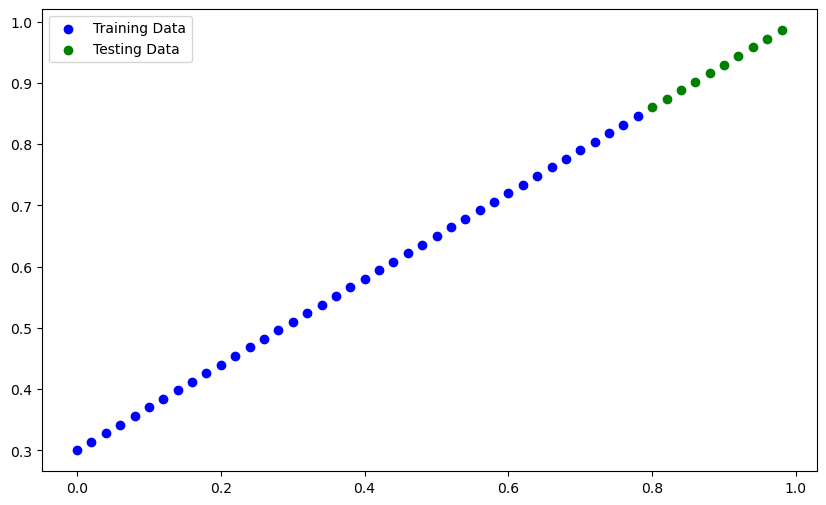

In [16]:
plot_predictions()

In [17]:
list(model_1.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [18]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [19]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1.parameters(),lr = 0.01)

In [22]:
torch.manual_seed(42)
epochs = 200
for epoch in range(epochs):
    model_1.train()
    
    y_pred1 = model_1(X_train)
    loss1 = loss_fn(y_pred1,y_train)
    optimizer.zero_grad()
    loss1.backward()
    optimizer.step()
    
    
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred,y_test)
        
        
    if epoch % 10 == 0:
        print(f"Epochs:{epoch} | Loss:{loss1} | Test_Loss:{test_loss}")

Epochs:0 | Loss:0.5551779866218567 | Test_Loss:0.5739762187004089
Epochs:10 | Loss:0.4399680197238922 | Test_Loss:0.4392663538455963
Epochs:20 | Loss:0.3247582018375397 | Test_Loss:0.30455657839775085
Epochs:30 | Loss:0.20954827964305878 | Test_Loss:0.16984674334526062
Epochs:40 | Loss:0.09433844685554504 | Test_Loss:0.03513689711689949
Epochs:50 | Loss:0.023886388167738914 | Test_Loss:0.04784906655550003
Epochs:60 | Loss:0.0199567973613739 | Test_Loss:0.04580312222242355
Epochs:70 | Loss:0.016517989337444305 | Test_Loss:0.0375305712223053
Epochs:80 | Loss:0.013089170679450035 | Test_Loss:0.029944902285933495
Epochs:90 | Loss:0.009653176181018353 | Test_Loss:0.02167237363755703
Epochs:100 | Loss:0.006215679459273815 | Test_Loss:0.014086711220443249
Epochs:110 | Loss:0.00278724217787385 | Test_Loss:0.005814164876937866
Epochs:120 | Loss:0.0012645028764382005 | Test_Loss:0.013801807537674904
Epochs:130 | Loss:0.0012645028764382005 | Test_Loss:0.013801807537674904
Epochs:140 | Loss:0.0012

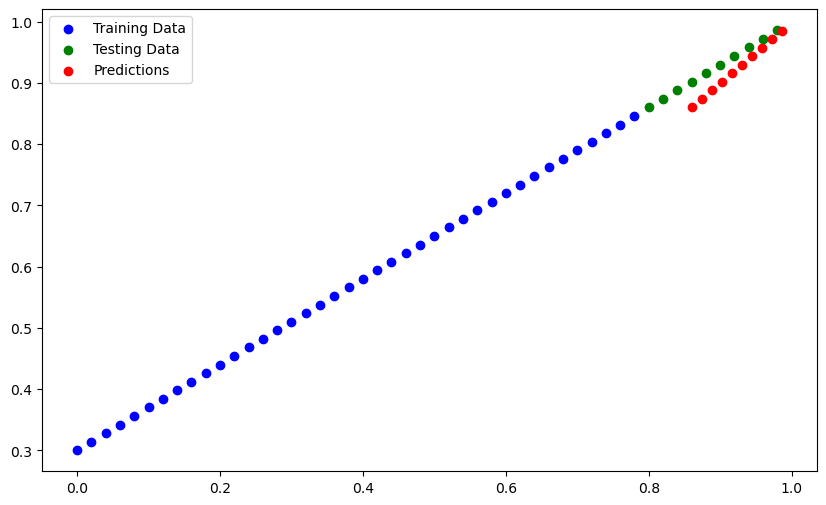

In [23]:
plot_predictions(predictions=test_pred)

In [24]:
with torch.inference_mode():
    y_pred_new = model_1(X_test)
    
y_pred_new

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

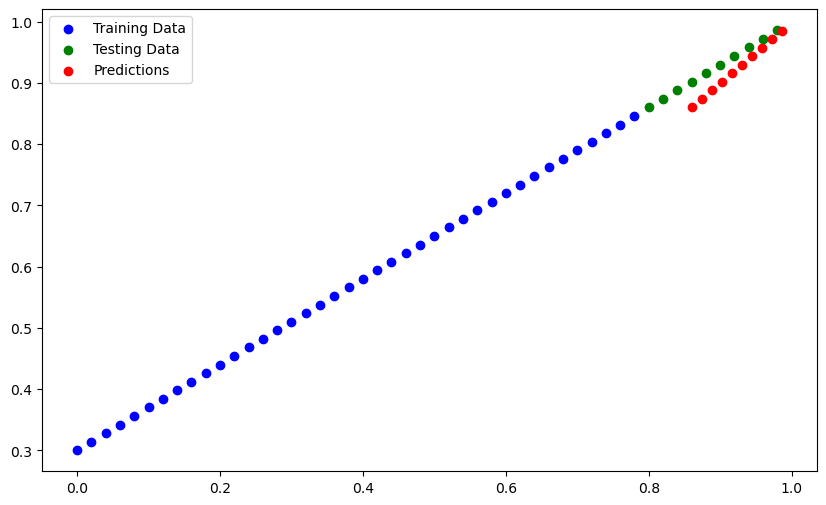

In [25]:
plot_predictions(predictions = y_pred_new)

In [26]:
from pathlib import Path

MODEL_PATH = Path("modelss")
MODEL_PATH.mkdir(exist_ok = True,parents=True)

MODEL_NAME = "02-Pytorch.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

PosixPath('modelss/02-Pytorch.pth')

In [27]:
print(f"Saving Model : {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(),f = MODEL_SAVE_PATH)


Saving Model : modelss/02-Pytorch.pth
